In [34]:
import numpy as np
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from sklearn.metrics import silhouette_score, davies_bouldin_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score
import joblib

# **0. CONTEXTO Y CARGA DATOS**

**Objetivo**:

Clasificar casas según su la región en la que se encuentren y del ingreso medio. Para ello, utilizaremos el famoso conjunto de datos California Housing. Se construyó utilizando los datos del censo de California de 1990. Contiene una fila por grupo de bloques censales. Un grupo de bloques es la unidad geográfica más pequeña para la que se publican datos del censo de USA.

In [2]:
df_completo=pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=809&path=housing.csv")
df_completo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [3]:
#Seleccionamos las variables de estudio
df=df_completo[["Latitude", "Longitude", "MedInc"]]
df.head(5)

,Latitude,Longitude,MedInc
0,37.88,-122.23,8.3252
1,37.86,-122.22,8.3014
2,37.85,-122.24,7.2574
3,37.85,-122.25,5.6431
4,37.85,-122.25,3.8462


# **1. CONFIGURACIÓN INICIAL**

## 1.1. Verificar missing values

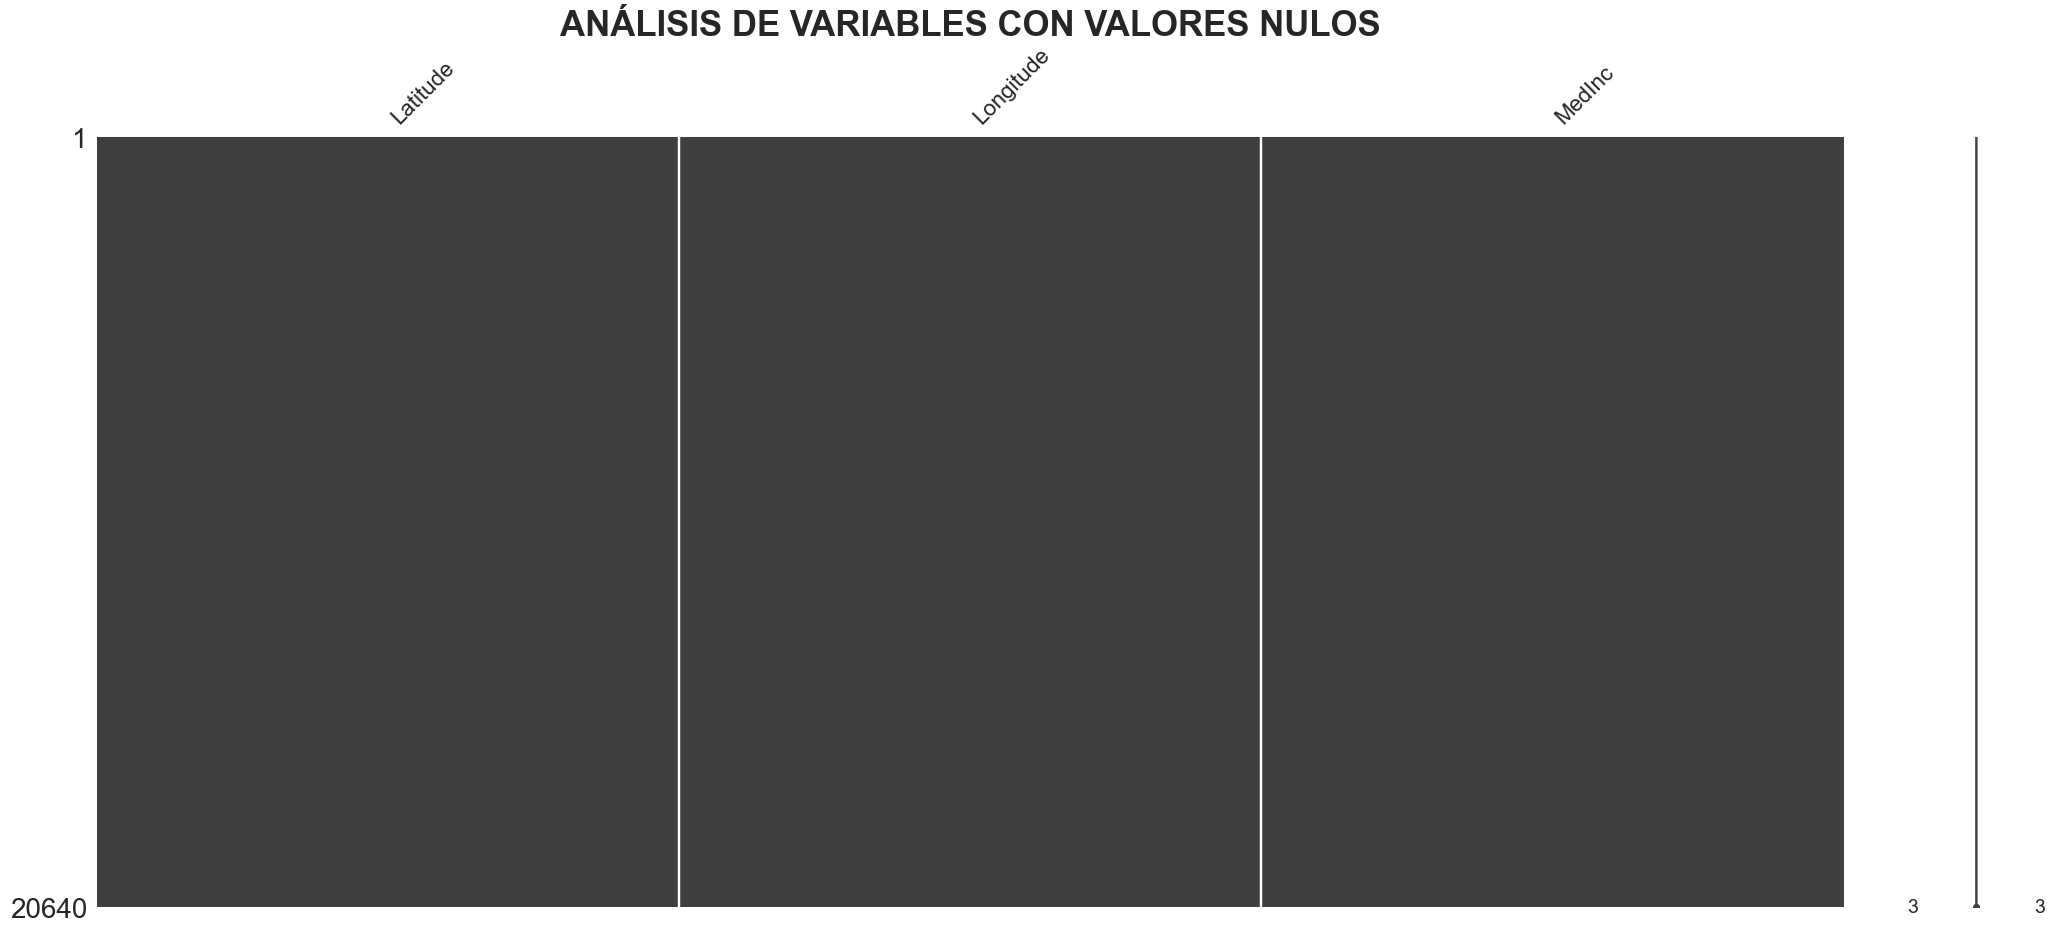

In [4]:
#Gráficamente
msno.matrix(df)
plt.title("ANÁLISIS DE VARIABLES CON VALORES NULOS", fontweight="bold", size=25)
plt.show()

## 1.3. División Train-Test

In [5]:
X_train, X_test=train_test_split(df, test_size=0.2, random_state=42)

## 1.4. Escalado de datos

In [6]:
#Instaciamos el escalador
scal=MinMaxScaler()
##Ajustamos y transformamos para train
train_sc=scal.fit_transform(X_train) #no es necesario escalar una variable con una escala cercana a 1 (0/1)
##Solo transformamos para test (independia base datos)
test_sc=scal.transform(X_test)

#Pasamos a df
##Train
X_train_sc=pd.DataFrame(train_sc, columns=X_train.columns, index=X_train.index)
##Test
X_test_sc=pd.DataFrame(test_sc, columns=X_test.columns, index=X_test.index)

In [7]:
X_train_sc.describe()

,Latitude,Longitude,MedInc
count,16512.000000,16512.000000,16512.000000
mean,0.329058,0.474871,0.233159
std,0.227305,0.199766,0.131329
min,0.000000,0.000000,0.000000
25%,0.146809,0.252988,0.142536
50%,0.181915,0.581673,0.210059
75%,0.550000,0.631474,0.294705
max,1.000000,1.000000,1.000000


# **2. MODELADO NO SUPERVISADO**

In [8]:
#Entrenamos el modelo de k means con 6 cluster
kmeans = KMeans(n_clusters=6, random_state=0)
kmeans.fit(X_train_sc)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",6
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


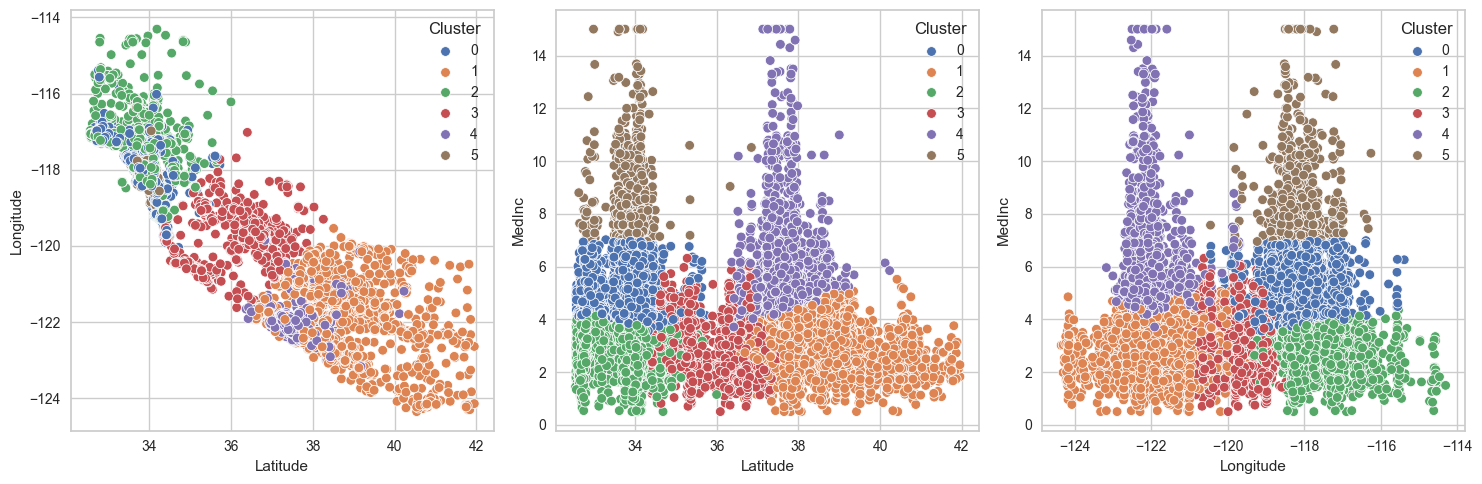

In [9]:
#Creamos copia de train
train=X_train.copy()
#Añadimos las etiquetas entrenadas
train['Cluster']=kmeans.labels_
fig, axis = plt.subplots(1, 3, figsize = (15, 5))

sns.scatterplot(ax = axis[0], data = train, x = "Latitude", y = "Longitude", hue = "Cluster", palette = "deep")
sns.scatterplot(ax = axis[1], data = train, x = "Latitude", y = "MedInc", hue = "Cluster", palette = "deep")
sns.scatterplot(ax = axis[2], data = train, x = "Longitude", y = "MedInc", hue = "Cluster", palette = "deep")
plt.tight_layout()

plt.show()

En los graficos 2 y 3 parece que la clusterización es correcta pues apararecen difrenciados correctamente cada grupo y, además, no se entrelazan. Sin embargo, en el primer gráfico se observar como esta dvisión no es tan pura. 

Para evitar error en los cluster evaluaremos si alterar su numero pueda mejorar su pureza.

## 2.1. Evaluación

In [10]:
# Computamos métricas
sil_score=[] # Distancia media de cada punto con el resto de centroides (maximizar)
dav_score=[] # Similitud media con respecto al centroide más cercano (minimizar)

for k in range(2,21):
    modelo=KMeans(n_clusters=k, random_state=0)
    modelo.fit(X_train_sc)
    sil_score.append(silhouette_score(X_train_sc, modelo.labels_))
    dav_score.append(davies_bouldin_score(X_train_sc, modelo.labels_))

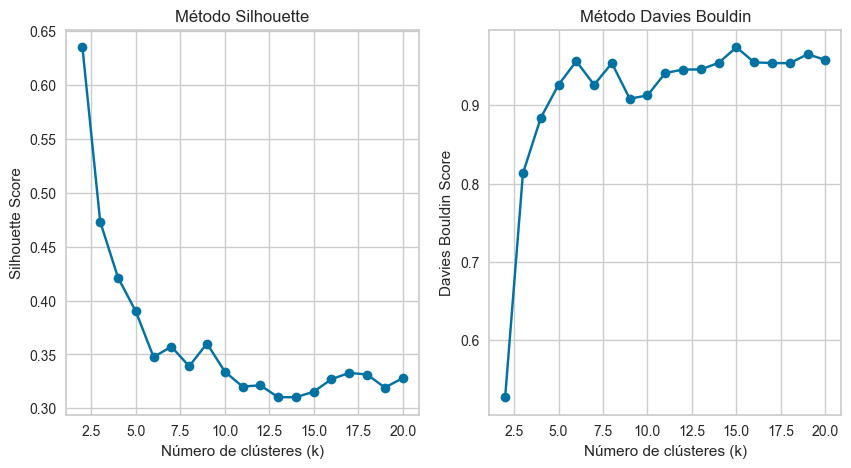

In [11]:
fig, axis = plt.subplots(1, 2, figsize = (10, 5))

axis[0].plot(range(2,21), sil_score, marker="o")
axis[0].set_title('Método Silhouette')
axis[0].set_xlabel('Número de clústeres (k)')
axis[0].set_ylabel('Silhouette Score')
axis[1].plot(range(2,21), dav_score, marker="o")
axis[1].set_title('Método Davies Bouldin')
axis[1].set_xlabel('Número de clústeres (k)')
axis[1].set_ylabel('Davies Bouldin Score')
plt.grid(True)
plt.show()

Atendiendo a las métricas, parece que establecer 6 cluster sería una seleción correcta pues para ese número se empieza a estabilizar las medidas, de forma que la inclusión de un numero mayor de cluster solo sobredimensionaria la escala categorica de la variable.

## 2.2. Predicción

In [12]:
#Guardamos los cluster en cada base de datos
##train
train=X_train.copy()
train["Cluster"]=kmeans.labels_
##test
test=X_test.copy()
test["Cluster"]=kmeans.predict(X_test_sc)
#Agregamos todo a una misma BBDD
df_cluster=pd.concat([train, test], axis=0)

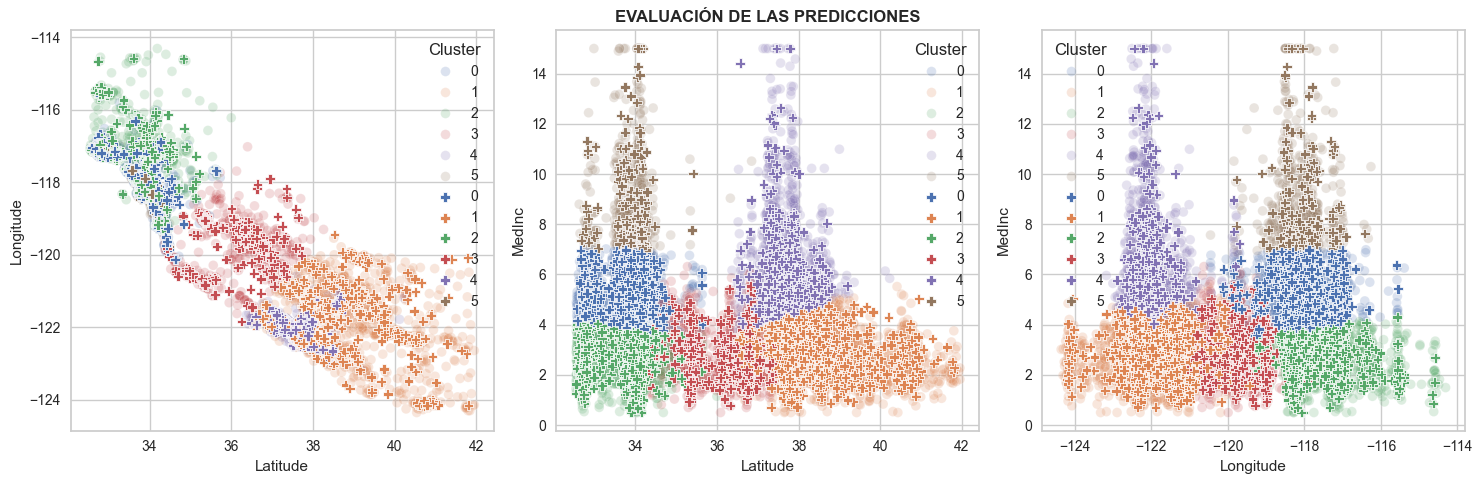

In [13]:
#Visualización del resultado
fig, axis = plt.subplots(1, 3, figsize = (15, 5))
#Train
sns.scatterplot(ax = axis[0], data = train, x = "Latitude", y = "Longitude", hue = "Cluster", palette = "deep", alpha=0.2)
sns.scatterplot(ax = axis[1], data = train, x = "Latitude", y = "MedInc", hue = "Cluster", palette = "deep", alpha=0.2)
sns.scatterplot(ax = axis[2], data = train, x = "Longitude", y = "MedInc", hue = "Cluster", palette = "deep", alpha=0.2)
#Test
sns.scatterplot(ax = axis[0], data = test, x = "Latitude", y = "Longitude", hue = "Cluster", palette = "deep", marker="P")
sns.scatterplot(ax = axis[1], data = test, x = "Latitude", y = "MedInc", hue = "Cluster", palette = "deep", marker="P")
axis[1].set_title("Evaluación de las predicciones".upper(), fontweight="bold")
sns.scatterplot(ax = axis[2], data = test, x = "Longitude", y = "MedInc", hue = "Cluster", palette = "deep", marker="P")
plt.tight_layout()
plt.show()

# **3. MODELADO SUPERVISADO**

In [ ]:
#Dividimos base de datos para el entrenamiento del modelo sin escalar las variables (arboles)
##train
X_train_mls=train.drop(columns="Cluster")
y_train=train["Cluster"]
##test
X_test_mls=test.drop(columns="Cluster")
y_test=test["Cluster"]


In [15]:
#Entrenamos el modelo
dt=DecisionTreeClassifier(random_state=42)
dt.fit(X_train_mls, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

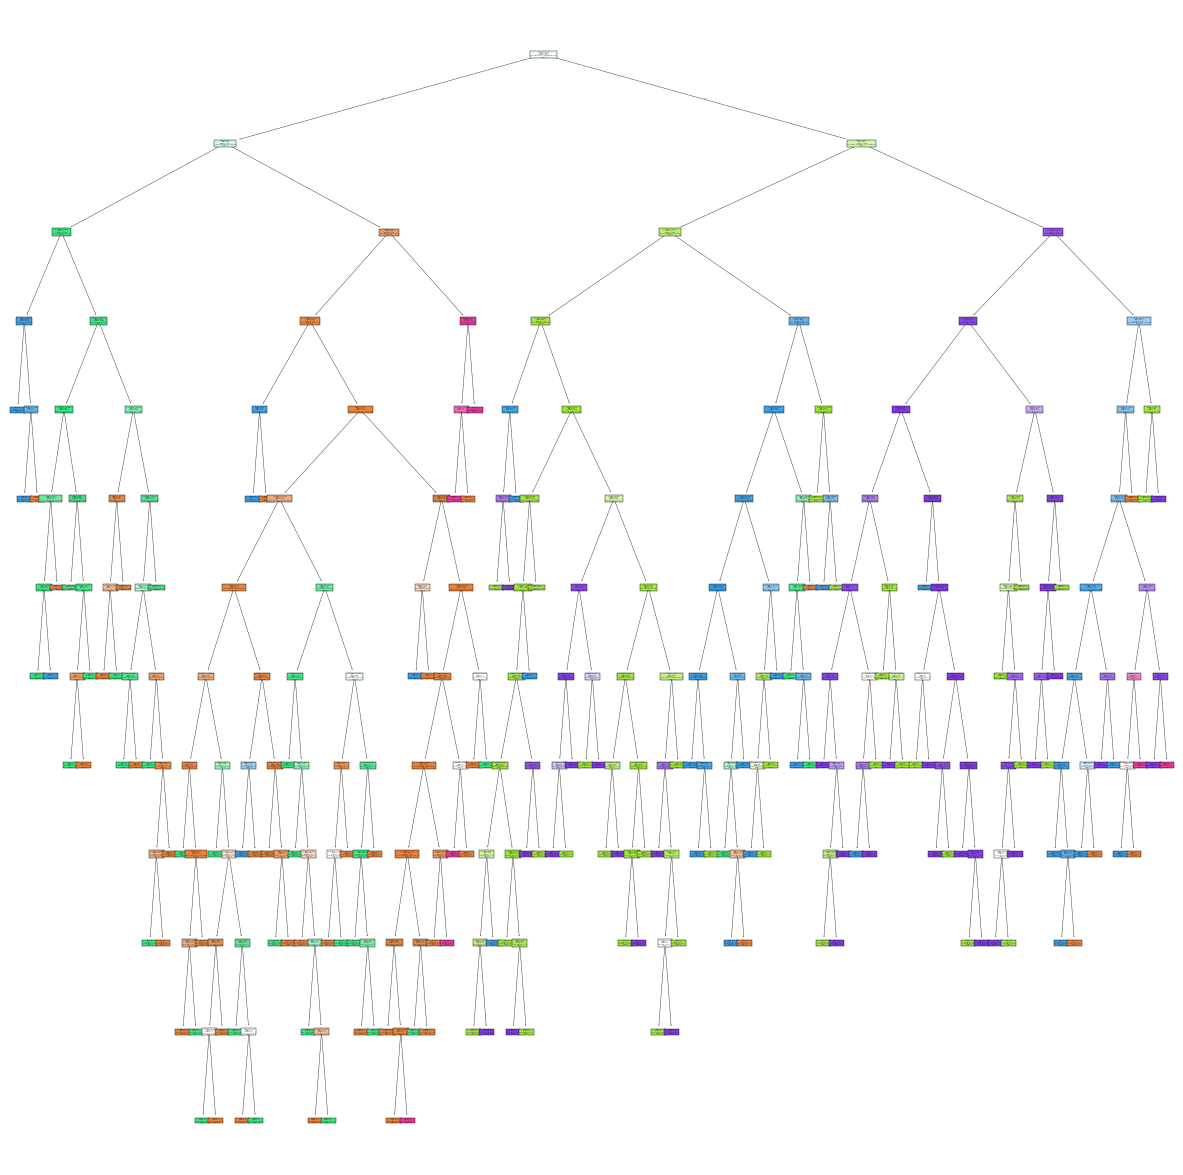

In [16]:
#Visualizamos el entrenamiento
fig = plt.figure(figsize=(15,15))
tree.plot_tree(dt, feature_names = list(X_train.columns), class_names = ["0", "1", "2", "3", "4", "5"], filled = True)
plt.show()

In [26]:
#Calculamos accuracy del modelo en test
print(f'El acierto promedio entre las 6 categorías es de: {round(accuracy_score(y_test, dt.predict(X_test_mls))*100, 2)}%')

El acierto promedio entre las 6 categorías es de: 99.25%


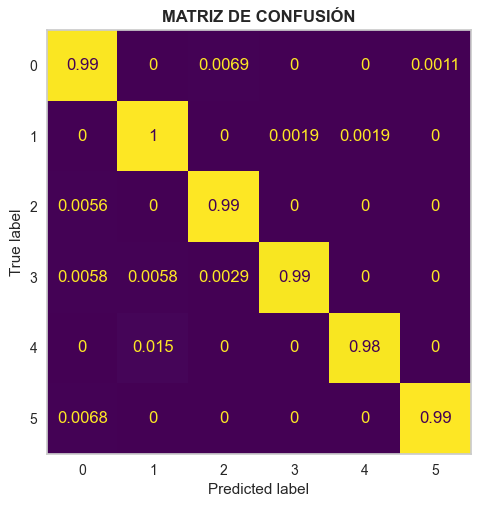

In [25]:
## Matriz de confusion
cm = confusion_matrix(y_test, dt.predict(X_test_mls), labels=[0,1,2,3,4,5], normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="viridis", colorbar=False)
plt.title("Matriz de confusión".upper(), fontweight='bold')
plt.grid(False)
plt.show()

A través de la matriz de confusión se aprecia como el acierto en la base de datos de prueba en cada categoría es bastante alto pues no llega a representar menos del 98% de los valores observados correctamente clasificados. Veamos a hora las características de cada categoria.

In [33]:
train.groupby("Cluster").mean().sort_values(by='MedInc', ascending=False)

,Latitude,Longitude,MedInc
Cluster,,,
5,33.891963,-118.111015,8.980360
4,37.643290,-122.010947,6.042401
0,33.871073,-118.020000,4.992714
1,38.332156,-121.888956,2.948101
3,36.061612,-119.725101,2.774989
2,33.799933,-117.792369,2.690248


Se aprecia como los *cluster 4 y 5* que se encuentran en norte, tuvieron unos **ingresos anuales mayores** (60.424$ y 89.803,6$, respectivamente). A medida que el *resto de clusters* se sitúan en zonas cercanas al sur de California, se aprecia como sus **ingresos disminuyen** significativamente a cifras cercanas a los **27.000-28.000$** anuales. De esta forma, podemos afirmar que la latitud en la que se viva dentro de California condiciona de manera significativa los ingresos medios del hogar.

# **4. Exportación de modelos**

In [35]:
#Exportamos el modelo con joblib (más rápido que pickle)
joblib.dump(kmeans, "09-Kmeans.joblib")
joblib.dump(dt, "09-DT.joblib")

['09-DT.joblib']